In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Importamos de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [4]:
ruta_proyecto = "../02_datos/03_Entrenamiento/"
ruta_df_tablon = ruta_proyecto + "04_df_tablon.pkl"

df = pd.read_pickle(ruta_df_tablon)

# Avisamos al usuario
print("✅ Dataframe df_tablon exportado correctamente")

✅ Dataframe df_tablon exportado correctamente


# 01. Métodos supervisados para selección de variables
---

## 1.1. Mutual Information

In [5]:
target = 'compra'

x = df.drop(columns=target).copy()
y = df[target].copy()

In [6]:
def ranking_mi(mutual_selector, modo='tabla'):
    #Maqueta ranking
    ranking_mi = pd.DataFrame(mutual_selector, index=x.columns).reset_index()
    ranking_mi.columns = ['variable', 'importancia_mi']
    ranking_mi = ranking_mi.sort_values(by= 'importancia_mi', ascending=False)
    ranking_mi['ranking_mi'] = np.arange(0, ranking_mi.shape[0])
    
    #Muestra la salida
    if modo == 'tabla':
        return (ranking_mi)
    
    else:
        g = ranking_mi.importancia_mi.sort_values().plot.barh(figsize = (12,10))
        g.set_yticklabels(ranking_mi.sort_values(by='importancia_mi').variable)
        return(g)

In [7]:
from sklearn.feature_selection import mutual_info_classif

mutual_selector = mutual_info_classif(x, y)

<Axes: >

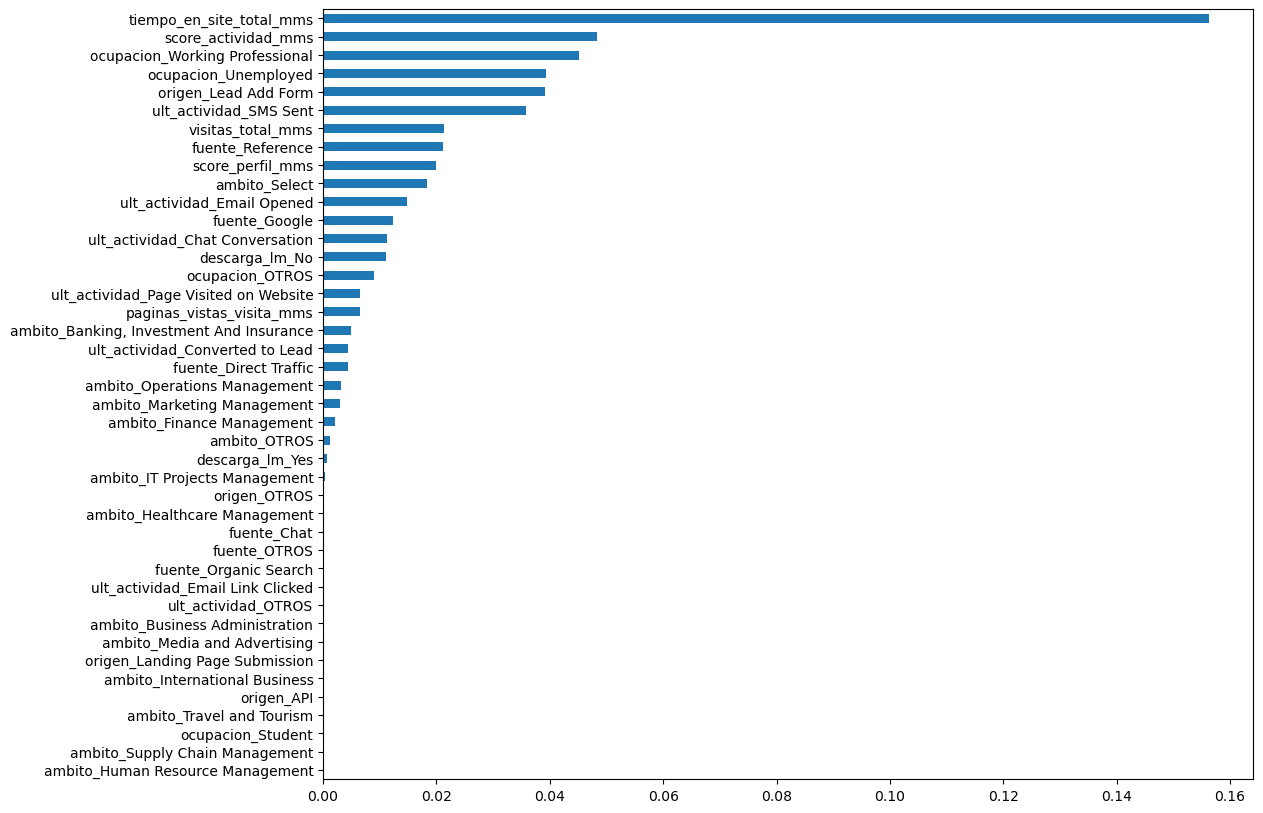

In [8]:
ranking_mi(mutual_selector, modo='grafico')

Observamos lo siguiente de este gráfico:
- `tiempo_site_total_mms` es el más predictiva sobre si nos compran o no. 
- `score`: 
- `ocupacion_unemployed`: si es desempleado o no también.
- `ocupacion_working Professional`: es la siguiente, muy de cerca.
- `ult_actividad_SMS_sent`.

Luego se observan las que no son nada predictivas como por ejemplo el `ambito_Marketing Management`, `ult_actividad_OTROS`, `ambito_Banking`, `Investment and Insurance`, etc. 

El corte lo vamos realizar incluyendo la última variable en: `ult_actividad_Converted to Lead`.

In [9]:
# Definir la posicion de la ultima variable
posicion_variable_limite = 19

In [10]:
# Extraer nombres que entran
entran_mi = ranking_mi(mutual_selector).iloc[0:posicion_variable_limite].variable

# Creo el dataframe
x_mi = x[entran_mi].copy()

## 1.2. Recursive Information

In [11]:
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

rfe = RFE(
    estimator=XGBClassifier(
        n_jobs=-1,
        eval_metric='auc'
    )
)

In [12]:
rfe.fit(x, y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).","XGBClassifier...ree=None, ...)"
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",None
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None


In [13]:
entran_rfe = x.columns[rfe.support_]; entran_rfe

Index(['origen_Landing Page Submission', 'origen_Lead Add Form',
       'ult_actividad_Chat Conversation', 'ult_actividad_Converted to Lead',
       'ult_actividad_Email Link Clicked', 'ult_actividad_OTROS',
       'ult_actividad_Page Visited on Website', 'ult_actividad_SMS Sent',
       'ambito_Finance Management', 'ambito_IT Projects Management',
       'ambito_Marketing Management', 'ambito_Select', 'ocupacion_OTROS',
       'ocupacion_Unemployed', 'ocupacion_Working Professional',
       'descarga_lm_No', 'visitas_total_mms', 'tiempo_en_site_total_mms',
       'paginas_vistas_visita_mms', 'score_actividad_mms', 'score_perfil_mms'],
      dtype='str')

In [14]:
x_rfe = x[entran_rfe].copy()

## 1.3. Permutation Importance

In [15]:
def ranking_per(predictoras, permutation):

    ranking_per = (
        pd.DataFrame({
            'variable': predictoras.columns,
            'importancia_per': permutation.importances_mean
        })
        .sort_values('importancia_per', ascending=False)
        .reset_index(drop=True)
    )

    ranking_per['ranking_per'] = np.arange(0, ranking_per.shape[0])

    return ranking_per

In [16]:
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings(action="ignore", message=r'.*Use subset.*of np.ndarray is not recommended')

xgb = XGBClassifier(
    n_jobs=-1,
    eval_metric='auc'
)

xgb.fit(x, y)

permutation = permutation_importance(
    xgb,
    x,
    y,
    scoring='roc_auc',
    n_repeats=5,
    n_jobs=-1
)

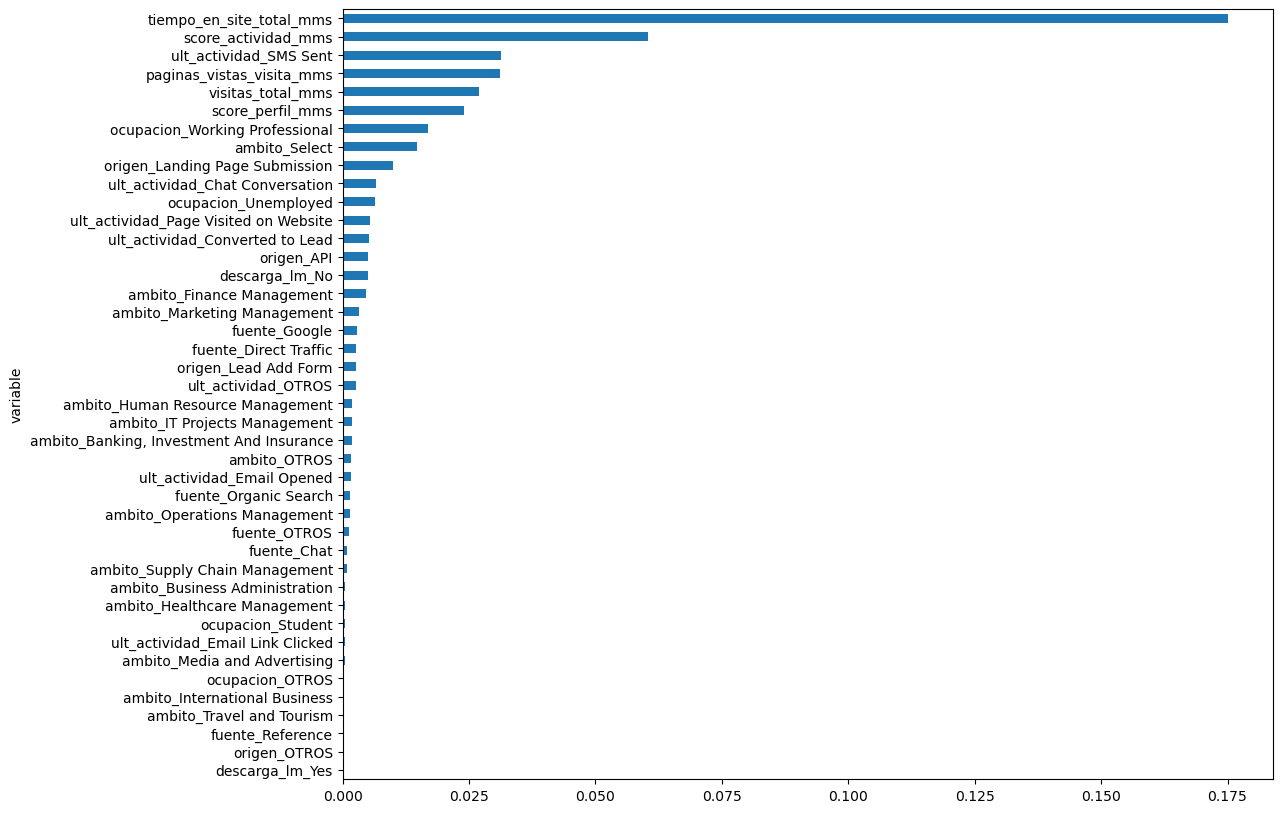

In [17]:
rank_per = ranking_per(x, permutation)
rank_per.set_index('variable').importancia_per.sort_values().plot.barh(figsize=(12,10));

Confiramos la misma información que el resultado de Mutual Information (tiempo_site_mms, SMS, score_actividad, working professional). Y luego ya tendríamos una cola larga hasta `descarga lm_NO`. Este último método sí que es cierto que parece que condensa más la información predictiva, por lo que, lo usaremos como referencia para seleccionar las variables ya que indica menos variables y evitamos la dimensionalidad.

Sin embargo, es de destacar que al dar **resultados similares todos ellos, cualquier podría ser válido**

In [18]:
posicion_variable_limite = 15

entran_per = rank_per.iloc[0:posicion_variable_limite].variable

In [19]:
x_per = x[entran_per].copy()

# Método Final de Supervisados

In [20]:
x_preseleccionado = x_per

# 02. Métodos NO supervisados para selección de variables
---

## 2.1. Correlación

In [21]:
def correlaciones_fuertes(df, lim_inf=0.3, lim_sup = 1, drop_dupli=True):
    
    # Matriz de correlaciones
    c = df.corr().abs()

    # Se pasa a filas
    c = c.unstack()

    # Índices a columnas y añadimos nombres
    c = pd.DataFrame(c).reset_index()
    c.columns = ['var1', 'var2', 'corr']

    # Pasamos a dataframe, filtramos límites y ordenamos descendentemente
    c = c.loc[(c['corr'] > lim_inf) & (c['corr'] < lim_sup),:].sort_values(by='corr', ascending=False)

    # Desduplica correlaciones (o no si drop_dupli = False)
    c = c if drop_dupli == False else c.drop_duplicates(subset=['corr']) 

    # Salida
    return(c)

In [22]:
cor_finales = correlaciones_fuertes(x_preseleccionado)

In [23]:
cor_finales.var1.value_counts()

var1
ambito_Select                3
descarga_lm_No               3
score_perfil_mms             2
paginas_vistas_visita_mms    2
origen_API                   1
ocupacion_Unemployed         1
Name: count, dtype: int64

Esto nos indica que las 4 primeras variables correlacionan con otras 3 variables. Si analizamos más en detalle el detallado, observamos que, por ejemplo, `origen_API`con `origen_Landing Page Submission` pero vamos a analizar sus poderes de predicción antes de decidir eliminar una u otra. Para ello, volvemos el gráfico anterior.

In [24]:
cor_finales.head(50)

,var1,var2,corr
203,origen_API,origen_Landing Page Submission,0.884
156,ocupacion_Unemployed,ocupacion_Working Professional,0.860
118,ambito_Select,origen_API,0.708
113,ambito_Select,origen_Landing Page Submission,0.694
218,descarga_lm_No,origen_Landing Page Submission,0.513
223,descarga_lm_No,origen_API,0.450
217,descarga_lm_No,ambito_Select,0.447
88,score_perfil_mms,origen_API,0.418
49,paginas_vistas_visita_mms,visitas_total_mms,0.390
110,ambito_Select,score_perfil_mms,0.358


In [25]:
a_eliminar_corr = ['origen_API', 'origen_Landing Page Submission']

In [26]:
x_preseleccionado.drop(columns=a_eliminar_corr, inplace=True)

In [27]:
x_preseleccionado.columns.to_list()

['tiempo_en_site_total_mms',
 'score_actividad_mms',
 'ult_actividad_SMS Sent',
 'paginas_vistas_visita_mms',
 'visitas_total_mms',
 'score_perfil_mms',
 'ocupacion_Working Professional',
 'ambito_Select',
 'ult_actividad_Chat Conversation',
 'ocupacion_Unemployed',
 'ult_actividad_Page Visited on Website',
 'ult_actividad_Converted to Lead',
 'descarga_lm_No']

In [32]:
# Unificamos en un dataset 
df_final = pd.concat([x_preseleccionado, y], axis=1)

# 3. Exportamos los datasets de preselección

In [37]:
# Rutas de carpetas
ruta_proyecto = "../02_datos/03_Entrenamiento/"
nombre_x_preseleccionado = ruta_proyecto + '06_x_preseleccionado.pkl'
nombre_y_preseleccionado = ruta_proyecto + '06_y_preseleccionado.pkl'
df_final_ruta = ruta_proyecto + '07_df_final.pkl'

# Exportamos y avisamos al usuario

try:
    # Guardamos el archivo
    x_preseleccionado.to_pickle(nombre_x_preseleccionado)

    y_preseleccionado = y.copy()
    y_preseleccionado.to_pickle(nombre_y_preseleccionado)
    
    df_final.to_pickle(df_final_ruta)

    print(f"✅ Dataframe {nombre_x_preseleccionado} y {nombre_y_preseleccionado} exportados correctamente")

except:
    print(f"❌ Dataframe {nombre_x_preseleccionado} y {nombre_y_preseleccionado} NO se han exportado")

✅ Dataframe ../02_datos/03_Entrenamiento/06_x_preseleccionado.pkl y ../02_datos/03_Entrenamiento/06_y_preseleccionado.pkl exportados correctamente


## Próximos pasos...
- Como **no se realiza Balanceo de clases**, pasaremos a la **Modelización**.